In [1]:
import glob as _glob
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

def get_inf_k_steps(data):
    return [k for r in data["runs"] for k in r["inference_sphere_k_steps"]]

def load(path):
    with open(path) as f:
        return json.load(f)

KN_PATHS = ["../data/fraud_k_step/20260416T104629Z/artifacts_with_k.json"] + sorted(_glob.glob("../data/fraud_k_step/**/artifacts_k*.json", recursive=True))
kn_data  = [load(p) for p in KN_PATHS]
kn_names = [Path(p).stem for p in KN_PATHS]
kn_steps = [get_inf_k_steps(d) for d in kn_data]

K_kn = 16
print(f"Loaded {len(kn_data)} files   K={K_kn}")

Loaded 17 files   K=16


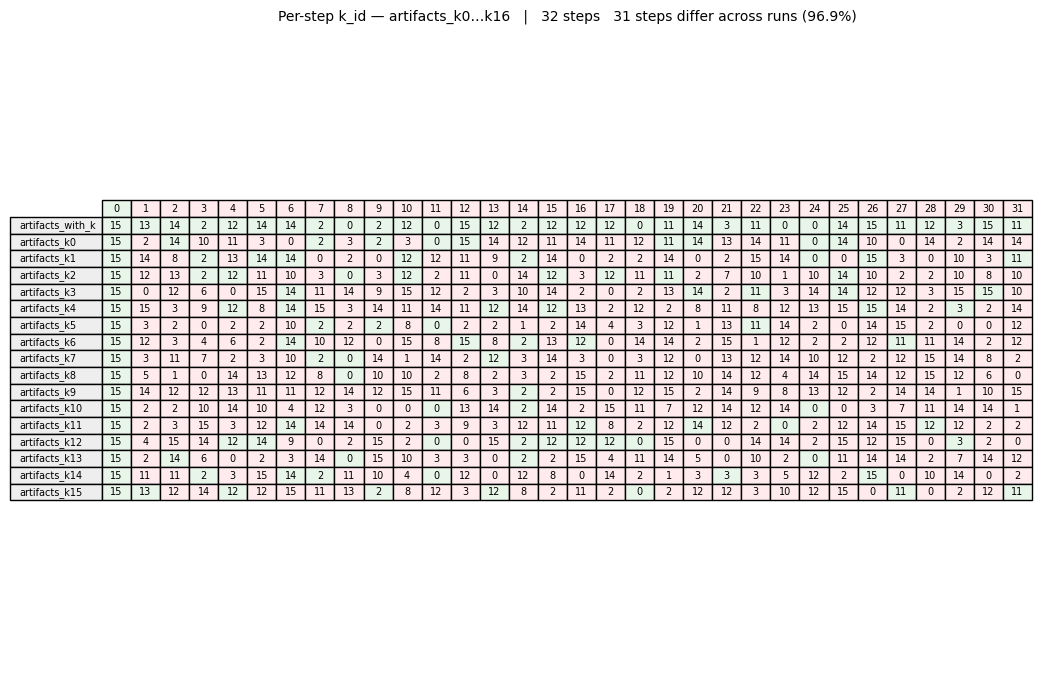

: 

In [ ]:
kn_arrays = [np.array(d["runs"][0]["inference_sphere_k_steps"]) for d in kn_data]

n = 32
kn_arrays = [a[:n] for a in kn_arrays]

all_match = np.ones(n, dtype=bool)
for a in kn_arrays:
    all_match &= (a == kn_arrays[0])
n_diff = (~all_match).sum()

match_color = "#e8f5e9"
miss_color  = "#ffebee"

col_labels  = [str(i) for i in range(n)]
rows        = [[str(a[i]) for i in range(n)] for a in kn_arrays]
cell_colors = [
    [match_color if a[i] == kn_arrays[0][i] else miss_color for i in range(n)]
    for a in kn_arrays
]

fig, ax = plt.subplots(figsize=(max(12, n * 0.32), 0.4 * len(kn_data) + 1.4))
ax.axis("off")
ax.set_title(
    f"Per-step k_id — artifacts_k0…k{len(kn_data)-1}   |   "
    f"{n} steps   {n_diff} steps differ across runs ({n_diff/n*100:.1f}%)",
    fontsize=10, pad=10,
)

tbl = ax.table(
    cellText=rows,
    rowLabels=kn_names,
    colLabels=col_labels,
    cellColours=cell_colors,
    rowColours=["#eeeeee"] * len(kn_data),
    colColours=[match_color if all_match[i] else miss_color for i in range(n)],
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7)
plt.show()